<a href="https://colab.research.google.com/github/shehzadtm/KhuramFiles/blob/main/Support_Resistance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_1467/1658812889.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period)
[*********************100%***********************]  1 of 1 completed



--- sndk Key Levels Found ---
Identified Support Levels ($): [np.float64(40.1), np.float64(183.0), np.float64(517.0), np.float64(558.58), np.float64(1230.8)]
Identified Resistance Levels ($): [np.float64(284.76), np.float64(691.54), np.float64(725.0), np.float64(777.6), np.float64(2354.39)]


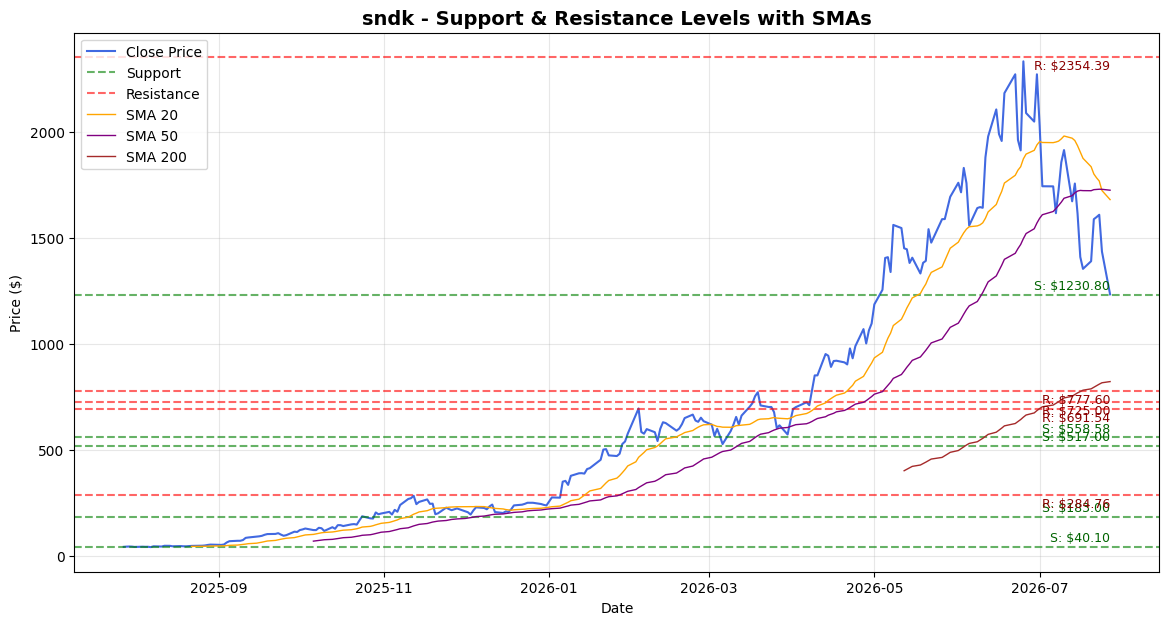


--- Trading Judgment for sndk ---
Current Price (2026-07-27): $1234.37
SMA 20: $1681.92, SMA 50: $1726.34, SMA 200: $822.40
Price is mixed relative to SMAs, indicating potential consolidation or uncertain trend.
No recent Golden Cross detected.
No recent Death Cross detected.
Last Price crossed above SMA 20 on: 2026-04-01.
Last Price crossed below SMA 20 on: 2026-07-02.
Nearest Support: $1230.80 (current price is 0.29% above).
Price is very close to a key support level. This could be a potential buying opportunity if it holds, or a bearish signal if it breaks.
Nearest Resistance: $2354.39 (current price is 90.74% below).
Overall Sentiment: Mixed long-term trend. Negative short-to-medium term momentum. Further technical analysis is recommended for a definitive 'Buy'/'Sell' decision.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
from scipy.signal import argrelextrema


def get_stock_data_and_levels(ticker, period="1y", window=10):
    """Downloads stock data, calculates support and resistance levels,
    and computes SMAs."""
    # 1. Download historical stock data
    df = yf.download(ticker, period=period)

    if df.empty:
        print(f"No data found for ticker: {ticker}")
        return None, None, None, None, None, None

    # Flatten columns if multi-indexed (fix for recent yfinance updates)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Calculate SMAs
    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['SMA_50'] = df['Close'].rolling(window=50).mean()
    df['SMA_200'] = df['Close'].rolling(window=200).mean()

    # 2. Find local maxima (Resistance) and minima (Support)
    # 'window' is the number of points to check on each side of the current point
    df["Min"] = df.iloc[
        argrelextrema(df["Low"].values, np.less_equal, order=window)[0]
    ]["Low"]
    df["Max"] = df.iloc[
        argrelextrema(df["High"].values, np.greater_equal, order=window)[0]
    ]["High"]

    # Extract unique price levels, dropping NaN entries
    supports = df["Min"].dropna().unique()
    resistances = df["Max"].dropna().unique()

    # 3. Filter out clusters that are too close to each other (consolidation)
    # We group levels that are within 1.5% of each other
    def merge_levels(levels, threshold_pct=0.015):
        if len(levels) == 0:
            return []
        sorted_levels = np.sort(levels)
        merged = []
        current_bin = [sorted_levels[0]]

        for r in sorted_levels[1:]:
            if (r - current_bin[-1]) / current_bin[-1] < threshold_pct:
                current_bin.append(r)
            else:
                merged.append(np.mean(current_bin))
                current_bin = [r]
        merged.append(np.mean(current_bin))
        return merged

    clean_supports = merge_levels(supports)
    clean_resistances = merge_levels(resistances)

    return df, clean_supports, clean_resistances


def plot_stock_data_with_levels_and_smas(df, ticker, supports, resistances):
    """Plots the stock closing price alongside the calculated levels and SMAs."""
    plt.figure(figsize=(14, 7))
    plt.plot(df.index, df["Close"], label="Close Price", color="royalblue", lw=1.5)

    # Plot cleaned Support lines
    for sup in supports:
        plt.axhline(
            y=sup,
            color="green",
            linestyle="--",
            alpha=0.6,
            label="Support" if sup == supports[0] else "", # Only label first instance
        )
        plt.text(df.index[-1], sup + (df['Close'].max() - df['Close'].min())*0.005, f'S: ${sup:.2f}', color='darkgreen', fontsize=9, verticalalignment='bottom', horizontalalignment='right')

    # Plot cleaned Resistance lines
    for res in resistances:
        plt.axhline(
            y=res,
            color="red",
            linestyle="--",
            alpha=0.6,
            label="Resistance" if res == resistances[0] else "", # Only label first instance
        )
        plt.text(df.index[-1], res - (df['Close'].max() - df['Close'].min())*0.005, f'R: ${res:.2f}', color='darkred', fontsize=9, verticalalignment='top', horizontalalignment='right')

    # Plot SMAs
    plt.plot(df.index, df['SMA_20'], label='SMA 20', color='orange', linestyle='-', lw=1)
    plt.plot(df.index, df['SMA_50'], label='SMA 50', color='purple', linestyle='-', lw=1)
    plt.plot(df.index, df['SMA_200'], label='SMA 200', color='brown', linestyle='-', lw=1)

    plt.title(f"{ticker} - Support & Resistance Levels with SMAs", fontsize=14, fontweight="bold")
    plt.xlabel("Date")
    plt.ylabel("Price ($)")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.show()

def analyze_entry_points(df, sup_levels, res_levels, ticker_symbol):
    """Analyzes the stock data for potential entry points based on SMA crossovers and S/R levels."""
    conclusion = [f"--- Trading Judgment for {ticker_symbol} ---"]

    current_price = df['Close'].iloc[-1]
    last_date = df.index[-1].strftime('%Y-%m-%d')
    conclusion.append(f"Current Price ({last_date}): ${current_price:.2f}")

    # SMA Status
    sma_20 = df['SMA_20'].iloc[-1] if not df['SMA_20'].isnull().all() else np.nan
    sma_50 = df['SMA_50'].iloc[-1] if not df['SMA_50'].isnull().all() else np.nan
    sma_200 = df['SMA_200'].iloc[-1] if not df['SMA_200'].isnull().all() else np.nan

    if not np.isnan(sma_20) and not np.isnan(sma_50) and not np.isnan(sma_200):
        conclusion.append(f"SMA 20: ${sma_20:.2f}, SMA 50: ${sma_50:.2f}, SMA 200: ${sma_200:.2f}")

        if current_price > sma_20 and current_price > sma_50 and current_price > sma_200:
            conclusion.append("Price is currently above all key moving averages (20, 50, 200-day SMAs), indicating strong bullish momentum.")
        elif current_price < sma_20 and current_price < sma_50 and current_price < sma_200:
            conclusion.append("Price is currently below all key moving averages (20, 50, 200-day SMAs), indicating strong bearish momentum.")
        elif current_price > sma_50 and current_price > sma_200:
            conclusion.append("Price is above the 50 and 200-day SMAs, suggesting a bullish trend, though it might be consolidating below SMA 20.")
        elif current_price < sma_50 and current_price < sma_200:
            conclusion.append("Price is below the 50 and 200-day SMAs, suggesting a bearish trend, though it might be consolidating above SMA 20.")
        else:
            conclusion.append("Price is mixed relative to SMAs, indicating potential consolidation or uncertain trend.")
    else:
        conclusion.append("Not enough data to calculate all SMAs for comparison.")

    # Golden Cross (50-day SMA crosses above 200-day SMA) - bullish signal
    if not df['SMA_50'].isnull().all() and not df['SMA_200'].isnull().all():
        golden_cross_dates = df[(df['SMA_50'].shift(1) < df['SMA_200'].shift(1)) &
                                (df['SMA_50'] > df['SMA_200'])].index

        if not golden_cross_dates.empty:
            conclusion.append(f"Golden Cross (SMA 50 > SMA 200) occurred on: {golden_cross_dates[-1].strftime('%Y-%m-%d')}. This is often considered a strong bullish signal.")
        else:
            conclusion.append("No recent Golden Cross detected.")

        # Death Cross (50-day SMA crosses below 200-day SMA) - bearish signal
        death_cross_dates = df[(df['SMA_50'].shift(1) > df['SMA_200'].shift(1)) &
                               (df['SMA_50'] < df['SMA_200'])].index

        if not death_cross_dates.empty:
            conclusion.append(f"Death Cross (SMA 50 < SMA 200) occurred on: {death_cross_dates[-1].strftime('%Y-%m-%d')}. This is often considered a strong bearish signal.")
        else:
            conclusion.append("No recent Death Cross detected.")

    # Price crossing above/below 20-day SMA
    if not df['SMA_20'].isnull().all():
        price_cross_20_dates = df[(df['Close'].shift(1) < df['SMA_20'].shift(1)) &
                                  (df['Close'] > df['SMA_20'])].index

        if not price_cross_20_dates.empty and price_cross_20_dates[-1] == df.index[-1]:
            conclusion.append(f"Price crossed above SMA 20 on the most recent day ({price_cross_20_dates[-1].strftime('%Y-%m-%d')}). This could indicate short-term upward momentum.")
        elif not price_cross_20_dates.empty:
            conclusion.append(f"Last Price crossed above SMA 20 on: {price_cross_20_dates[-1].strftime('%Y-%m-%d')}.")

        price_cross_20_below_dates = df[(df['Close'].shift(1) > df['SMA_20'].shift(1)) &
                                        (df['Close'] < df['SMA_20'])].index
        if not price_cross_20_below_dates.empty and price_cross_20_below_dates[-1] == df.index[-1]:
            conclusion.append(f"Price crossed below SMA 20 on the most recent day ({price_cross_20_below_dates[-1].strftime('%Y-%m-%d')}). This could indicate short-term downward momentum.")
        elif not price_cross_20_below_dates.empty:
            conclusion.append(f"Last Price crossed below SMA 20 on: {price_cross_20_below_dates[-1].strftime('%Y-%m-%d')}.")

    # Proximity to Support/Resistance
    nearest_support = None
    if sup_levels:
        # Closest support below current price
        supports_below = [s for s in sup_levels if current_price > s]
        if supports_below:
            nearest_support = max(supports_below)
        else:
            # If no supports below, find the closest one overall (could be above)
            nearest_support = min(sup_levels, key=lambda x: abs(x - current_price))

    nearest_resistance = None
    if res_levels:
        # Closest resistance above current price
        resistances_above = [r for r in res_levels if r > current_price]
        if resistances_above:
            nearest_resistance = min(resistances_above)
        else:
            # If no resistances above, find the closest one overall (could be below)
            nearest_resistance = min(res_levels, key=lambda x: abs(x - current_price))

    if nearest_support is not None:
        dist_to_support_pct = ((current_price - nearest_support) / nearest_support) * 100
        conclusion.append(f"Nearest Support: ${nearest_support:.2f} (current price is {dist_to_support_pct:.2f}% above).")
        if 0 < dist_to_support_pct < 2: # Within 2% above support
            conclusion.append("Price is very close to a key support level. This could be a potential buying opportunity if it holds, or a bearish signal if it breaks.")
        elif dist_to_support_pct < 0:
             conclusion.append("Price is below a key support level. This could be a bearish signal, potentially turning the old support into new resistance.")

    if nearest_resistance is not None:
        dist_to_resistance_pct = ((nearest_resistance - current_price) / current_price) * 100
        conclusion.append(f"Nearest Resistance: ${nearest_resistance:.2f} (current price is {dist_to_resistance_pct:.2f}% below).")
        if 0 < dist_to_resistance_pct < 2: # Within 2% below resistance
            conclusion.append("Price is very close to a key resistance level. This could indicate a selling opportunity or a potential breakout if it crosses.")
        elif dist_to_resistance_pct < 0:
             conclusion.append("Price is above a key resistance level. This could be a bullish signal, potentially turning the old resistance into new support.")

    final_recommendation = "Overall Sentiment: "
    # Simplified recommendation logic
    if current_price > sma_50 and current_price > sma_200 and not np.isnan(sma_50) and not np.isnan(sma_200):
        final_recommendation += "Bullish long-term trend. "
    elif current_price < sma_50 and current_price < sma_200 and not np.isnan(sma_50) and not np.isnan(sma_200):
        final_recommendation += "Bearish long-term trend. "
    else:
        final_recommendation += "Mixed long-term trend. "

    if current_price > sma_20 and current_price > sma_50 and not np.isnan(sma_20) and not np.isnan(sma_50):
        final_recommendation += "Positive short-to-medium term momentum. "
    elif current_price < sma_20 and current_price < sma_50 and not np.isnan(sma_20) and not np.isnan(sma_50):
        final_recommendation += "Negative short-to-medium term momentum. "

    if nearest_support is not None and (0 < ((current_price - nearest_support) / nearest_support) * 100 < 2) and current_price > sma_20:
        final_recommendation += "Potential 'Buy' opportunity if support holds with positive short-term momentum."
    elif nearest_resistance is not None and (0 < ((nearest_resistance - current_price) / current_price) * 100 < 2) and current_price < sma_20:
        final_recommendation += "Potential 'Sell' or 'Hold' near resistance with negative short-term momentum."
    elif nearest_resistance is not None and current_price > nearest_resistance and current_price > sma_20:
        final_recommendation += "Price has broken above resistance, which can be a strong bullish signal. Consider 'Buy' on retest of old resistance as new support."
    elif nearest_support is not None and current_price < nearest_support and current_price < sma_20:
        final_recommendation += "Price has broken below support, which can be a strong bearish signal. Consider 'Sell' on retest of old support as new resistance."
    else:
        final_recommendation += "Further technical analysis is recommended for a definitive 'Buy'/'Sell' decision."

    conclusion.append(final_recommendation)
    return "\n".join(conclusion)


# --- User Configuration ---
ticker_symbol = "sndk"  # <--- Change this to analyze a different stock
analysis_period = "1y"
window_size = 10 # For argrelextrema in S/R calculation

# --- Data Fetching and Analysis ---
df, sup_levels, res_levels = get_stock_data_and_levels(
    ticker_symbol, period=analysis_period, window=window_size
)

if df is None or df.empty:
    print(f"Could not retrieve data for {ticker_symbol}. Please check the ticker symbol or period.")
else:
    print(f"\n--- {ticker_symbol} Key Levels Found ---")
    print("Identified Support Levels ($):", [round(x, 2) for x in sup_levels])
    print("Identified Resistance Levels ($):", [round(x, 2) for x in res_levels])

    # Plotting
    plot_stock_data_with_levels_and_smas(df, ticker_symbol, sup_levels, res_levels)

    # Trading Judgment
    trading_judgment = analyze_entry_points(df, sup_levels, res_levels, ticker_symbol)
    print("\n" + trading_judgment)